## PCA and Clustering on USArrests data
---

Perform PCA and clustering on the USArrests.csv dataset, which contains:

- Arrests per 100,000 residents for Murder, Assault, Rape

- Percentage of UrbanPop (people in urban areas)
for each of the 50 US states in 1973.

---
## Import Modules

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

from matplotlib.patches import FancyArrow

---
## Load Data

In [16]:
data = pd.read_csv("UsArrests.csv", index_col=0)
data.index.name = "State"


# Display the first few rows of the dataset, its info, and summary statistics
print("First five rows of the dataset:")
data.head()


First five rows of the dataset:


,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


---
## Data Exploration

In [17]:
# Display summary statistics
print("\nSummary statistics:")
print(data.describe())


Summary statistics:
         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  14.474763   9.366385
min     0.80000   45.000000  32.000000   7.300000
25%     4.07500  109.000000  54.500000  15.075000
50%     7.25000  159.000000  66.000000  20.100000
75%    11.25000  249.000000  77.750000  26.175000
max    17.40000  337.000000  91.000000  46.000000


In [18]:
# Missing values per column
print("\nMissing values per column:")
print(data.isnull().sum())


Missing values per column:
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


---
## Correlation Matrix Of The Original Data

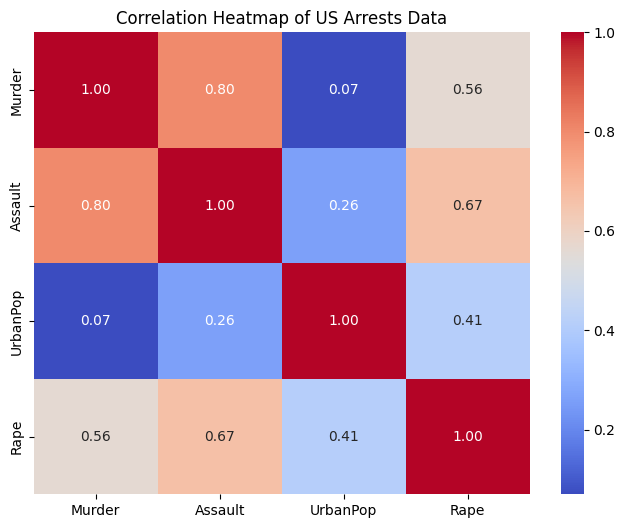

In [19]:
# Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of US Arrests Data")
plt.show()

**Correlation analysis & interpretation**

Key observations:
- Murder and Assault: Strong positive correlation (0.80).  
  - States with higher murder rates also tend to have higher assault rates.
  
- Assault and Rape: Moderately strong correlation (0.67).  
  - Areas with more assaults generally have more rape incidents reported.

- Murder and Rape: Moderate correlation (0.56).

- UrbanPop: Weak correlation with Murder (0.07) and Assault (0.26), but slightly stronger with Rape (0.41).  
  - This suggests that the percentage of urban population is not a strong predictor of violent crime rates.

**Conclusion:**  
Overall, violent crimes such as murder, assault, and rape tend to rise together across states, indicating they may be driven by similar underlying factors. However, urbanization (as measured by UrbanPop) does not show strong linear relationships with these crime rates.


---
## Data Scaling And PCA

In [20]:
# Data Scaling
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# PCA for explained variance
pca_full = PCA()
pca_full.fit(data_scaled)


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


---
## Biplot With The Transformed Data

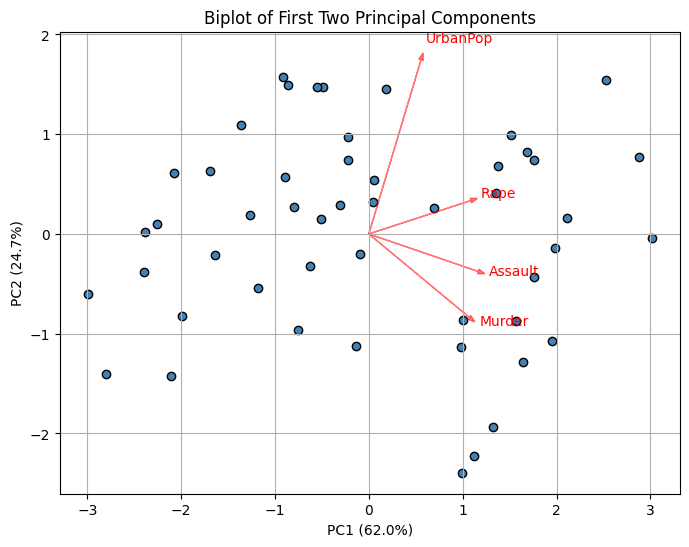

In [21]:
def biplot(score, coeff, explained_var, labels=None):
    xs = score[:,0]
    ys = score[:,1]
    plt.figure(figsize=(8,6))
    plt.scatter(xs, ys, c='steelblue', edgecolors='k')

    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i,0]*2, coeff[i,1]*2,
                  color='r', alpha=0.5, head_width=0.05)
        if labels is None:
            plt.text(coeff[i,0]*2.2, coeff[i,1]*2.2, "Var"+str(i+1), color='r')
        else:
            plt.text(coeff[i,0]*2.2, coeff[i,1]*2.2, labels[i], color='r')

    plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
    plt.grid()
    plt.title("Biplot of First Two Principal Components")
    plt.show()

   

# PCA for projection
pca_2d = PCA(n_components=2)
principalComponents = pca_2d.fit_transform(data_scaled)
 
biplot(principalComponents, np.transpose(pca_2d.components_), 
       explained_var=pca_2d.explained_variance_ratio_, 
       labels=data.columns) 


**Interpretation of the biplot**

The biplot shows how states are distributed along the first two principal components and how the original variables contribute to these components.

- Murder, Assault, and Rape arrows point in similar directions, indicating these crimes are positively correlated and largely define PC1.

- UrbanPop points differently, showing it is less correlated with the violent crime variables.

- States that lie far along the direction of these arrows have higher rates for those crimes.

- This confirms our earlier correlation analysis and highlights that the first principal component primarily captures variations in violent crime rates across states.


---
## Select the number of principal components to use in further analyses. 

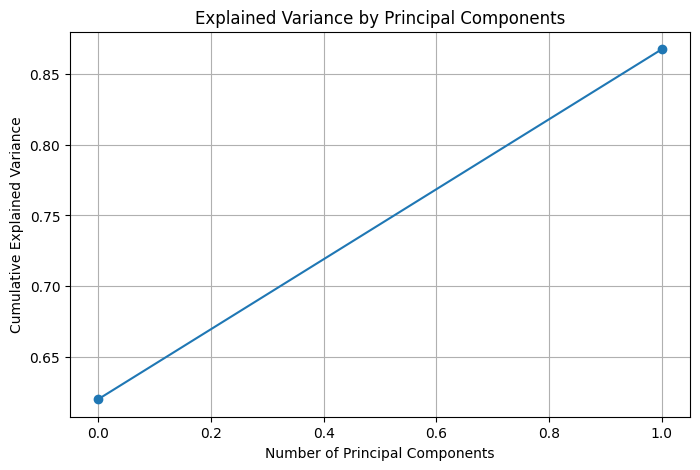

In [22]:
# Plot explained variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_2d.explained_variance_ratio_), marker='o')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


### Selecting the number of principal components

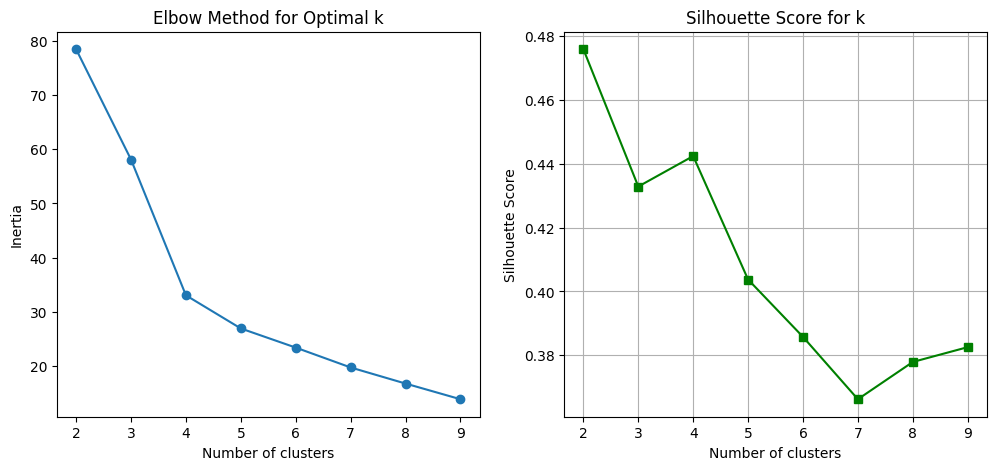

In [23]:
# Elbow method
inertia = []
silhouette_scores = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    preds = km.fit_predict(principalComponents)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(principalComponents, preds))

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='s', color='green')
plt.title("Silhouette Score for k")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


**Selecting the number of principal components**

Based on the cumulative explained variance plot:

- PC1 captures ~62% of the variance.
- PC2 adds up to ~86% of the total variance explained.
- Including PC3 raises this to ~97%, but the marginal gain is small.

Therefore, the first two principal components are selected for further analyses (such as clustering), as they together capture most of the dataset's variability while keeping the analysis interpretable and visually clear.


---
## Data Clustering

**Clustering 1: KMeans**

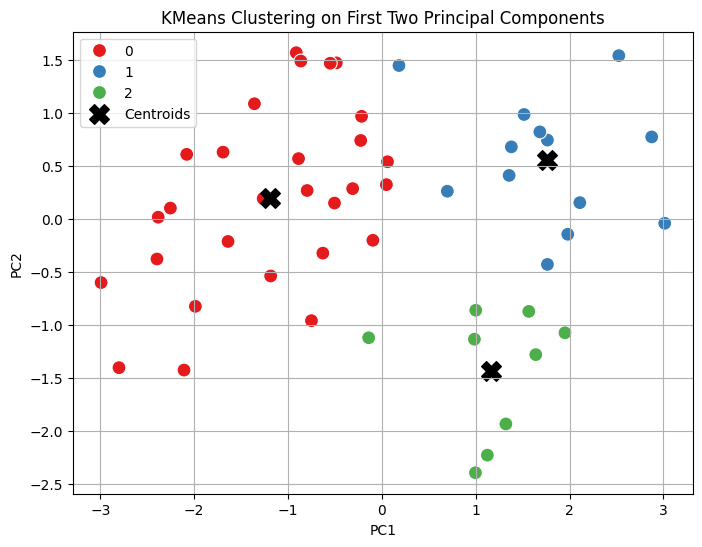

In [24]:
# Apply KMeans clustering on the first two PCs
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_kmeans = kmeans.fit_predict(principalComponents)

# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=principalComponents[:,0], y=principalComponents[:,1], 
                hue=clusters_kmeans, palette="Set1", s=100)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            color='black', marker='X', s=200, label='Centroids')
plt.title("KMeans Clustering on First Two Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

**Clustering 2: Hierarchical Clustering**

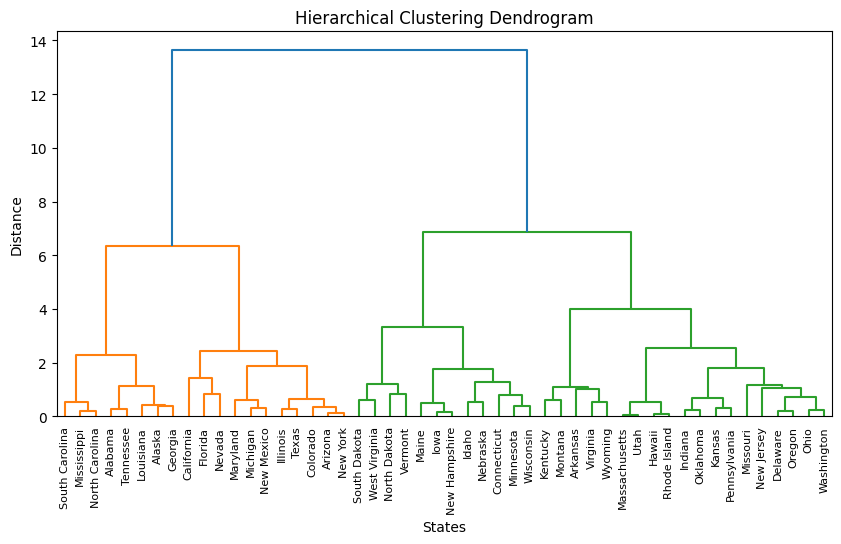

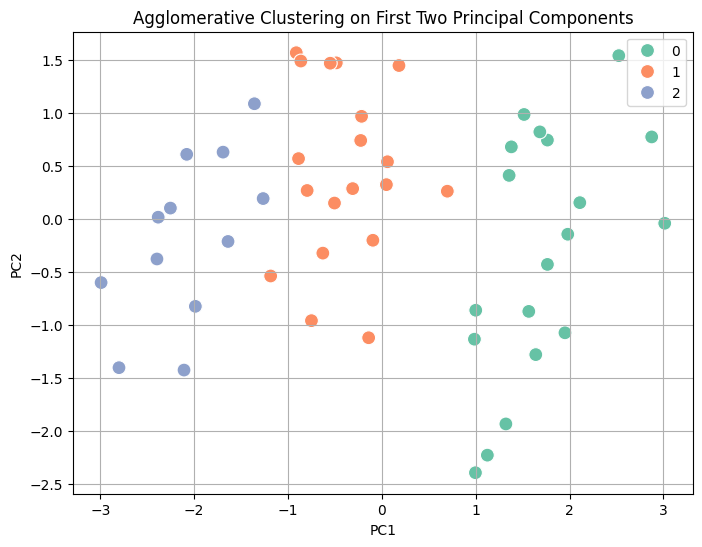

In [26]:
# Dendrogram
plt.figure(figsize=(10,5))
linked = linkage(principalComponents, method='ward')
dendrogram(linked, labels=data.index, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("States")
plt.ylabel("Distance")
plt.show()

# Apply Agglomerative clustering
agglo = AgglomerativeClustering(n_clusters=3)
clusters_agglo = agglo.fit_predict(principalComponents)

# Plot Agglomerative clustering
plt.figure(figsize=(8,6))
sns.scatterplot(x=principalComponents[:,0], y=principalComponents[:,1], 
                hue=clusters_agglo, palette="Set2", s=100)
plt.title("Agglomerative Clustering on First Two Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()


---
## Cluster analysis on the first two principal components

We performed clustering using **KMeans** and **Hierarchical Clustering** on the first two principal components.

**Clustering results:**
- Both clustering methods identified similar groups of states.
- The main driver of clustering is the variation in Murder, Assault, and Rape rates, which strongly influence PC1.
- UrbanPop has less influence on these clusters, consistent with its weaker loading on PC1 and PC2.

**Common patterns in clusters:**
- One cluster contains states with high murder and assault rates, often also elevated rape rates.
- Another cluster groups states with low crime rates, irrespective of urban population.
- A third cluster shows moderate crime levels.

**Conclusion:**
- By clustering in the space defined by the first two principal components, we focus on the most important patterns in the data. 
- This confirms that violent crime rates are the key factors distinguishing states, while the percentage of urban population plays a lesser role.
